In [ ]:
# splitting the skills on the basis of ;
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

data = pd.read_csv("/content/resume_dataset.csv")
skills = data["skills_required"].str.split(";")
print(data["skills_required"].dtype)
user = data["user_skill"].str.split(";")

mlb = MultiLabelBinarizer()
skills_required = mlb.fit_transform(skills)
user_skill = mlb.transform(user)
print(data.head(5))

'''
we have used this method to give
1-> if the user have the skill which is required
0-> user doesn't have the skill

'''
encoded_skill_required =pd.DataFrame(skills_required,columns = mlb.classes_)
encoded_user_required =pd.DataFrame(user_skill,columns = mlb.classes_)

object
   user_id education  experience user_location  \
0        1    Master           0     Port Said   
1        2  Bachelor           6    Alexandria   
2        3  Bachelor           0    Alexandria   
3        4    Master           8         Cairo   
4        5  Bachelor           7     Port Said   

                                          user_skill  \
0                                   SQL;C++;Java;CSS   
1                                    CSS;SQL;PyTorch   
2  Deep Learning;Machine Learning;C++;SQL;PyTorch...   
3  CSS;Java;NLP;TensorFlow;Machine Learning;JavaS...   
4                                       SQL;Java;NLP   

                             skills_required                  job_title  \
0                   NLP;Deep Learning;Python             Data Scientist   
1  Machine Learning;TensorFlow;Deep Learning  Machine Learning Engineer   
2                   Deep Learning;Python;SQL             Data Scientist   
3                        JavaScript;C++;Java         So

In [ ]:
#Creating the new column of skill , which are matched and
# converting the education into numerical data

data["Matched_skills"] = (encoded_user_required & encoded_skill_required).sum(axis=1)
data["education"] = data["education"].astype("string").str.strip().str.title()
edu_map={
    "PhD":1,
    "Master":2,
    "Bachelor":3
}

data["education"] = data["education"].map(edu_map)
data["education"] = data["education"].fillna(0).astype(int)


Accuracy on training data is :  98.0
Accuracy on the testing data is:  99.0


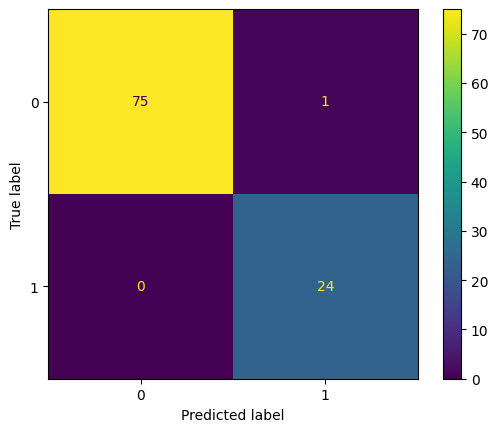

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

X=data[["education","Matched_skills","relevance_score","experience"]]
Y=data["selected"]

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.20,random_state=2)

model = LogisticRegression()
model.fit(X_train,y_train)

y_predictions = model.predict(X_train)

#predicting the accuracy on the training data
training_data_accuracy = accuracy_score(y_train,y_predictions)
print("Accuracy on training data is : ",training_data_accuracy*100)

# predicting the data on the test data
y_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(y_test,y_prediction)
print("Accuracy on the testing data is: ", test_data_accuracy*100)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_prediction)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [ ]:
#predictive system

num = int(input("Enter the number of skills u have: "))
user_skill = []
for i in range(num):
  skill = input(f"Enter the skill Number: {i+1}")
  user_skill.append(skill.title())

experiance = int(input("Enter the Experiance: "))

# skill required for the particular job
required_skill = ["Deep Learning","Python","SQL"]

user=[user_skill]
skills =[required_skill]

mlb = MultiLabelBinarizer()
skills_required = mlb.fit_transform(skills)
user_skill = mlb.transform(user)


predictive_user =pd.DataFrame(skills_required,columns = mlb.classes_)
predictive_required =pd.DataFrame(user_skill,columns = mlb.classes_)

# predicting the Mateched Skills

Matched_skills =( predictive_required & predictive_user ).sum(axis=1).iloc[0]

print(Matched_skills)


Enter the number of skills u have: 1
Enter the skill Number: 1python
Enter the Experiance: 4
1


In [ ]:
# giving the actual values for the prediction
#X=data[["education","Matched_skills","relevance_score","experience"]]

import numpy as np

relevance_score = Matched_skills /len(required_skill)

input = (2,Matched_skills,relevance_score,experiance)

input_numpy_shape = np.asarray(input)

input_reshape_numpy = input_numpy_shape.reshape(1,-1)


prediction = model.predict(input_reshape_numpy)
if prediction == 0:
  print("resume not selected ")
else:
  print("resume selected")



resume not selected 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
